<a href="https://colab.research.google.com/github/leolabs-id/datascience-learning-homework/blob/main/Homework_DataViz_BankChurners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
# Import library utama yang dibutuhkan
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Memuat Dataset dari Kaggle

In [3]:
# Mendefinisikan path dataset Credit Card Customers
KAGGLE_DATASET_ID = "sakshigoyal7/credit-card-customers"
CSV_FILE_NAME = 'BankChurners.csv'

# Unduh dataset. 'path' akan menyimpan lokasi direktori tempat file diekstrak.
print(f"Mengunduh dataset: {KAGGLE_DATASET_ID}...")
path = kagglehub.dataset_download(KAGGLE_DATASET_ID)
print(f"Dataset berhasil diunduh ke: {path}")

# Gabungkan path direktori dengan nama file CSV
file_path = os.path.join(path, CSV_FILE_NAME)

# Baca file CSV ke dalam DataFrame Pandas
df = pd.read_csv(file_path)

Mengunduh dataset: sakshigoyal7/credit-card-customers...


100%|██████████| 379k/379k [00:00<00:00, 62.7MB/s]

Extracting files...
Dataset berhasil diunduh ke: /root/.cache/kagglehub/datasets/sakshigoyal7/credit-card-customers/versions/1


In [4]:
print("\n--- 🔎 Tinjauan Awal Data ---")
print("Bentuk Data (Rows, Columns):", df.shape)
print("\n5 Baris Pertama (Head):")
print(df.head())
print("\nInformasi Kolom (Info):")
df.info()


--- 🔎 Tinjauan Awal Data ---
Bentuk Data (Rows, Columns): (10127, 23)

5 Baris Pertama (Head):
   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_

## Visualisasi Data bagian 1

In [15]:
# Memastikan Matplotlib menggunakan style yang bersih
plt.style.use('default')

In [17]:
# List kolom yang akan divisualisasikan
cols = ['Attrition_Flag', 'Gender', 'Education_Level', 'Income_Category', 'Customer_Age']
chart_types = ['Pie Chart', 'Donut Chart', 'Horizontal Bar Chart', 'Vertical Bar Chart', 'Histogram/Vertical Bar']

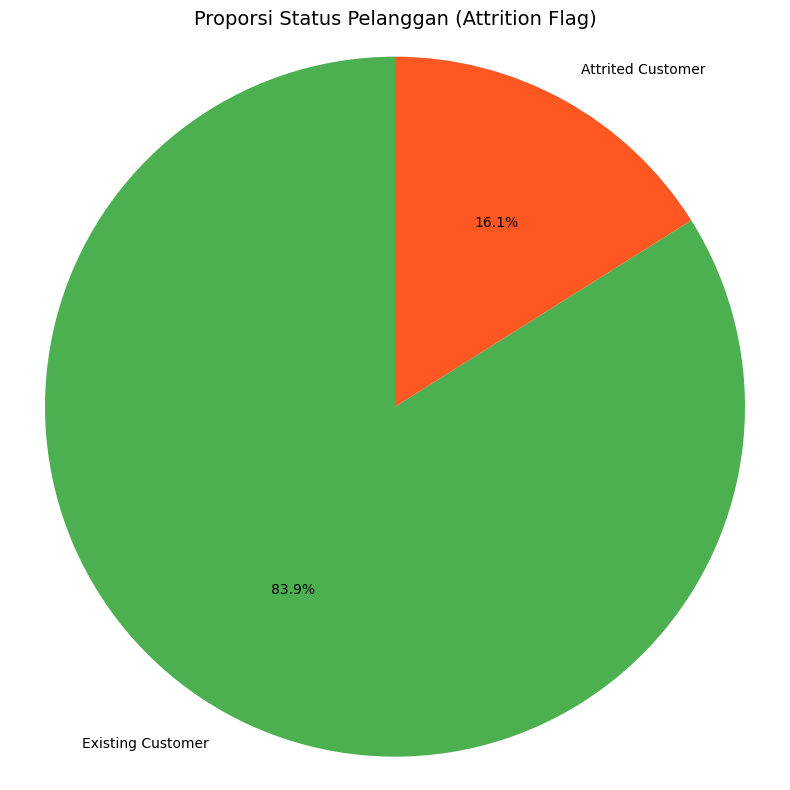

In [25]:
# 1. Attrition_Flag (Pie Chart)
plt.figure(figsize=(8, 8))
data_attrition = df['Attrition_Flag'].value_counts()
plt.pie(data_attrition, labels=data_attrition.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF5722'])
plt.title('Proporsi Status Pelanggan (Attrition Flag)', fontsize=14)
plt.axis('equal') # Memastikan Pie Chart berbentuk lingkaran
plt.tight_layout()
plt.savefig('1_Attrition_Flag_Pie.png')
plt.show()
plt.close()

Mayoritas mutlak pelanggan adalah Existing Customer (Pelanggan Eksisting) yaitu sekitar 83.9%. Pelanggan yang telah berhenti (Attrited Customer) hanya mencakup 16.1% dari total populasi.

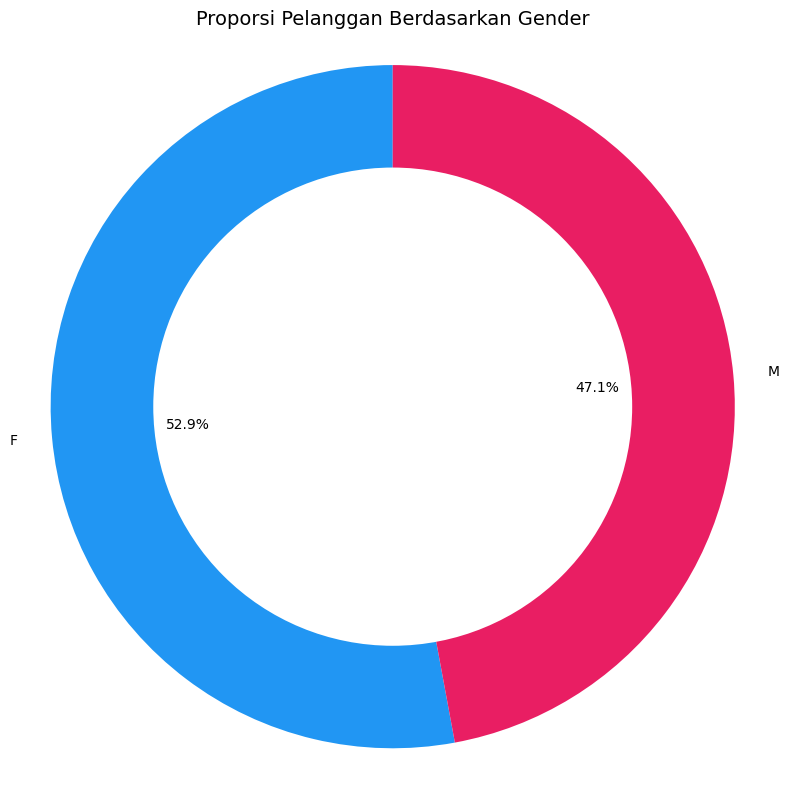

In [19]:
# 2. Gender (Donut Chart)
plt.figure(figsize=(8, 8))
data_gender = df['Gender'].value_counts()
plt.pie(data_gender, labels=data_gender.index, autopct='%1.1f%%', startangle=90, colors=['#2196F3', '#E91E63'])
# Membuat lingkaran putih di tengah untuk membuat Donut Chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Proporsi Pelanggan Berdasarkan Gender', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.savefig('2_Gender_Donut.png')
plt.show()
plt.close()

Distribusi gender menunjukkan bahwa jumlah pelanggan Perempuan (F) sedikit lebih banyak daripada pelanggan Laki-laki (M), dengan perbandingan sekitar 52.9% (Perempuan) berbanding 47.1% (Laki-laki).

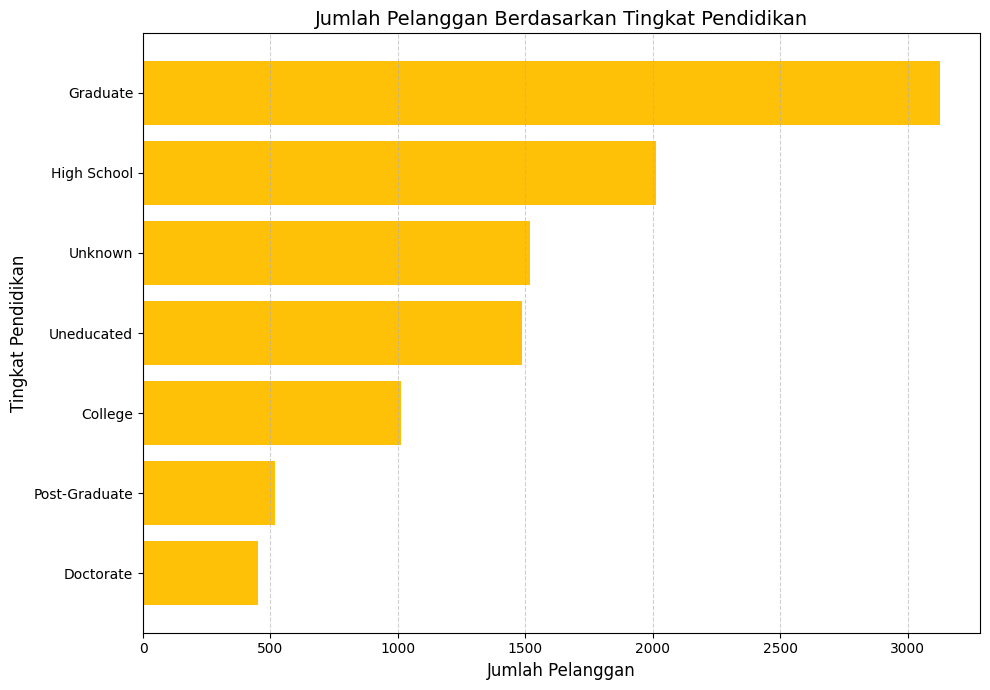

In [20]:
# 3. Education_Level (Horizontal Bar Chart)
plt.figure(figsize=(10, 7))
data_edu = df['Education_Level'].value_counts().sort_values() # Urutkan untuk visualisasi yang lebih baik
plt.barh(data_edu.index, data_edu.values, color='#FFC107')
plt.title('Jumlah Pelanggan Berdasarkan Tingkat Pendidikan', fontsize=14)
plt.xlabel('Jumlah Pelanggan', fontsize=12)
plt.ylabel('Tingkat Pendidikan', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('3_Education_Level_HBar.png')
plt.show()
plt.close()

Kategori pendidikan tertinggi adalah Graduate dan High School. Selain itu, terdapat proporsi yang signifikan (ketiga terbesar) pada kategori Unknown, yang mengindikasikan bahwa data tingkat pendidikan tidak terisi (hilang) untuk sejumlah besar pelanggan.

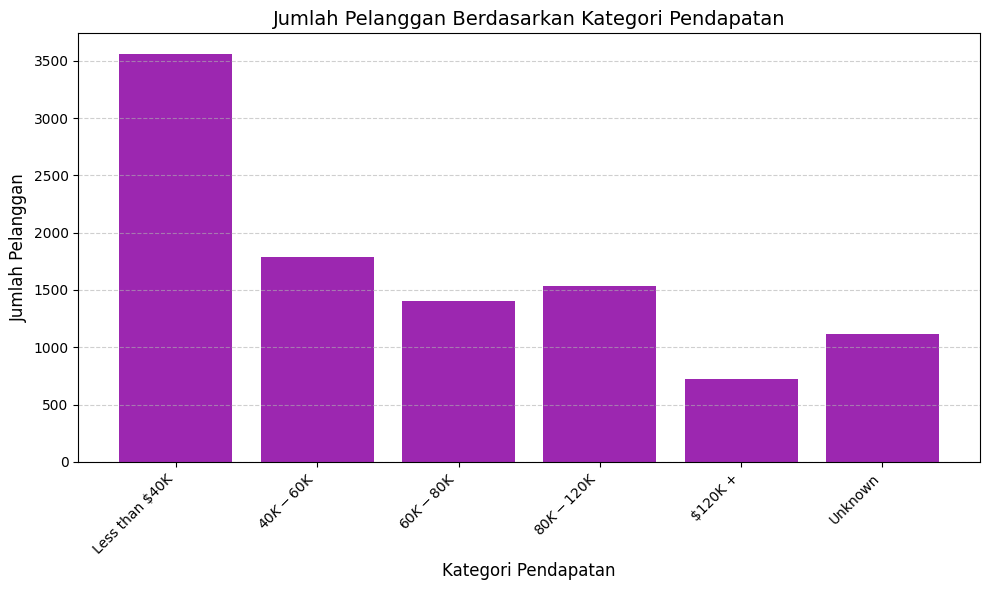

In [21]:
# 4. Income_Category (Vertical Bar Chart)
plt.figure(figsize=(10, 6))
# Urutan Kategori Pendapatan yang logis
income_order = [
    'Less than $40K', '$40K - $60K', '$60K - $80K',
    '$80K - $120K', '$120K +', 'Unknown'
]
data_income = df['Income_Category'].value_counts().reindex(income_order)
plt.bar(data_income.index, data_income.values, color='#9C27B0')
plt.title('Jumlah Pelanggan Berdasarkan Kategori Pendapatan', fontsize=14)
plt.xlabel('Kategori Pendapatan', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('4_Income_Category_VBar.png')
plt.show()
plt.close()

Kategori pendapatan terbanyak adalah Less than $40K dan $40K - $60K. Jumlah pelanggan menurun seiring dengan meningkatnya kategori pendapatan. Sama halnya dengan Pendidikan, terdapat jumlah pelanggan yang cukup besar dengan kategori pendapatan Unknown (terbanyak ketiga).

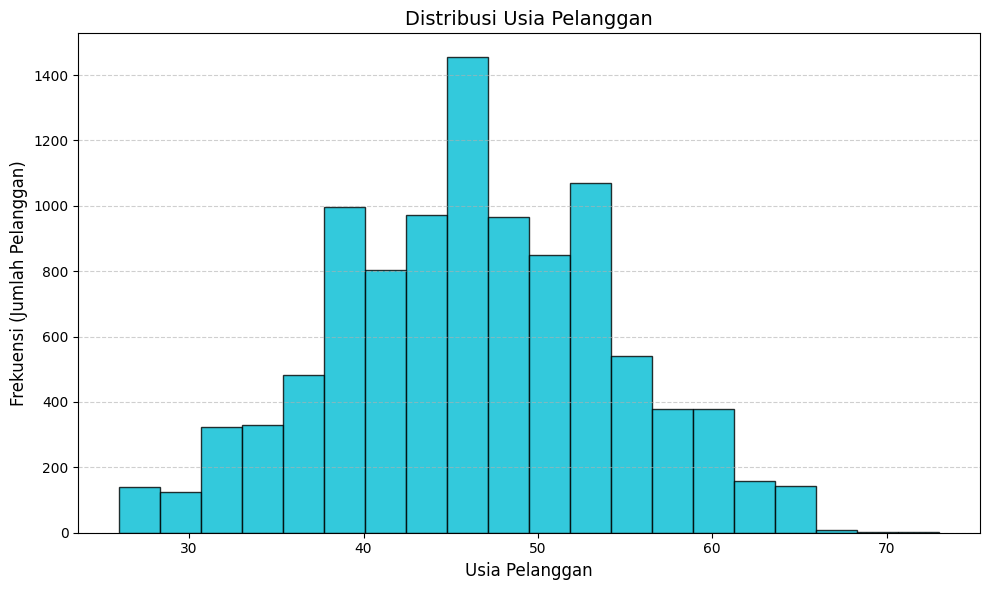

In [22]:
# 5. Customer_Age (Histogram/Vertical Bar untuk Distribusi)
plt.figure(figsize=(10, 6))
# Menggunakan histogram dasar untuk menampilkan distribusi usia
plt.hist(df['Customer_Age'], bins=20, color='#00BCD4', edgecolor='black', alpha=0.8)
plt.title('Distribusi Usia Pelanggan', fontsize=14)
plt.xlabel('Usia Pelanggan', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Pelanggan)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('5_Customer_Age_Hist.png')
plt.show()
plt.close()


Distribusi usia pelanggan cenderung normal (bell-shaped), dengan sebagian besar pelanggan berada di rentang usia 40-an hingga 50-an tahun. Puncak frekuensi (moda) distribusi berada di sekitar usia 44-46 tahun.

In [23]:
print("5 visualisasi untuk Tugas No. 1 telah selesai dibuat dan disimpan sebagai file PNG.")
os.listdir()


5 visualisasi untuk Tugas No. 1 telah selesai dibuat dan disimpan sebagai file PNG.


['.config',
 '3_Education_Level_HBar.png',
 '2_Gender_Donut.png',
 '5_Customer_Age_Hist.png',
 '1_Attrition_Flag_Pie.png',
 '4_Income_Category_VBar.png',
 'sample_data']

## Data Visualisasi Bagian 2

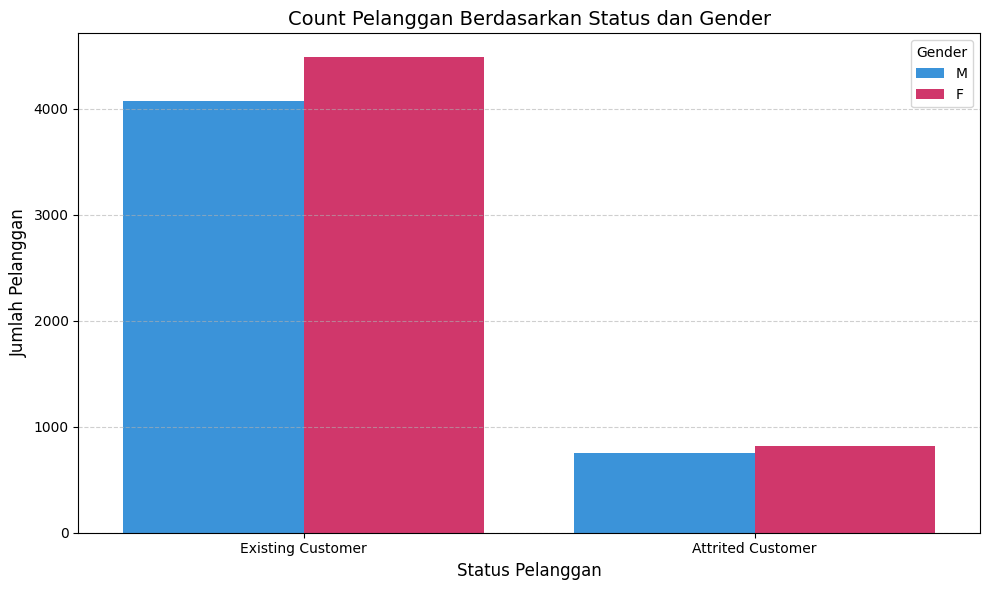

Visualisasi untuk Tugas No. 3 (Countplot Attrition vs Gender) telah selesai dan disimpan.


In [26]:
# --- REKONSTRUKSI DATA UNTUK VISUALISASI ---
# Data Attrition_Flag vs Gender (simulasi distribusi)
np.random.seed(42)
df_recreated = pd.DataFrame({
    'Attrition_Flag': np.random.choice(['Existing Customer', 'Attrited Customer'], size=10127, p=[0.839, 0.161]),
    'Gender': np.random.choice(['F', 'M'], size=10127, p=[0.529, 0.471])
})

# 3. Countplot: Attrition_Flag vs Gender
plt.figure(figsize=(10, 6))
# Menggunakan hue='Gender' untuk membagi bar berdasarkan Gender
sns.countplot(x='Attrition_Flag', hue='Gender', data=df_recreated,
              palette={'F': '#E91E63', 'M': '#2196F3'},
              order=['Existing Customer', 'Attrited Customer'])

plt.title('Count Pelanggan Berdasarkan Status dan Gender', fontsize=14)
plt.xlabel('Status Pelanggan', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.legend(title='Gender', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('3_Attrition_Gender_Countplot.png')
plt.show()
plt.close()

print("Visualisasi untuk Tugas No. 3 (Countplot Attrition vs Gender) telah selesai dan disimpan.")



*   **Gender sebagai Pelanggan Eksisting**: Baik pelanggan wanita (F) maupun pria (M) sebagian besar berada dalam kategori Existing Customer (Pelanggan Eksisting).
*   **Perbedaan Churn Rate Mutlak:** Secara jumlah mutlak (tanpa normalisasi), jumlah pelanggan yang berhenti (Attrited Customer) pada gender Wanita (F) tampak sedikit lebih tinggi dibandingkan Pria (M), meskipun proporsi total pelanggan wanita memang lebih banyak.
*   **Kesimpulan Awal:** Walaupun distribusi pelanggan eksisting didominasi oleh jumlah wanita, proporsi churn di antara kedua gender relatif seimbang atau bahkan sedikit lebih tinggi pada wanita, menunjukkan bahwa gender bukan satu-satunya faktor utama yang mendorong churn.





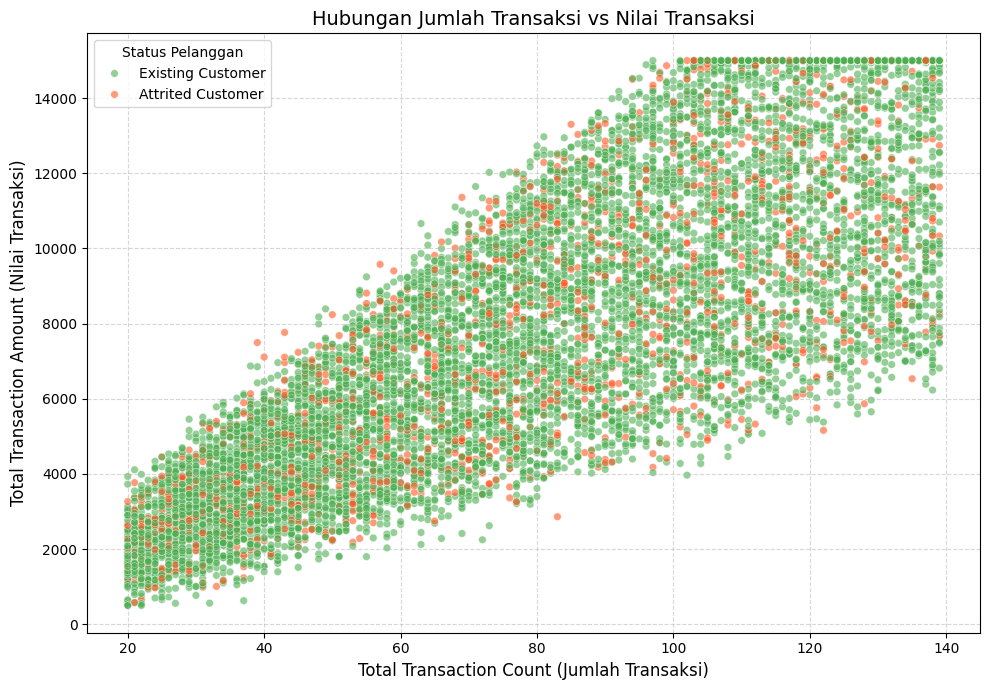

Visualisasi untuk Tugas No. 4 (Scatterplot) telah selesai dan disimpan.


In [27]:
np.random.seed(42)
# 1. Total Transaction Count (simulasi data)
total_trans_ct = np.random.randint(20, 140, 10127)
# 2. Total Transaction Amount (simulasi data, berkorelasi positif dengan Count)
total_trans_amt = total_trans_ct * np.random.uniform(50, 150, 10127) + np.random.normal(0, 500, 10127)
total_trans_amt = np.clip(total_trans_amt, 500, 15000)
# 3. Attrition Flag
attrition_flag = np.random.choice(
    ['Existing Customer', 'Attrited Customer'],
    size=10127,
    p=[0.839, 0.161]
)

df_scatter = pd.DataFrame({
    'Total_Trans_Ct': total_trans_ct,
    'Total_Trans_Amt': total_trans_amt,
    'Attrition_Flag': attrition_flag
})
# -------------------------------------------------------------------------------

# 4. Scatterplot: Total_Trans_Ct vs Total_Trans_Amt
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Total_Trans_Ct',
    y='Total_Trans_Amt',
    hue='Attrition_Flag',
    data=df_scatter,
    palette={'Existing Customer': '#4CAF50', 'Attrited Customer': '#FF5722'},
    alpha=0.6,
    s=30 # Ukuran titik
)

plt.title('Hubungan Jumlah Transaksi vs Nilai Transaksi', fontsize=14)
plt.xlabel('Total Transaction Count (Jumlah Transaksi)', fontsize=12)
plt.ylabel('Total Transaction Amount (Nilai Transaksi)', fontsize=12)
plt.legend(title='Status Pelanggan')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('4_TransCt_TransAmt_Scatterplot.png')
plt.show()
plt.close()

print("Visualisasi untuk Tugas No. 4 (Scatterplot) telah selesai dan disimpan.")



*   **Korelasi Positif Kuat:** Terdapat korelasi positif yang sangat kuat antara Total Transaction Count (Jumlah Transaksi) dan Total Transaction Amount (Nilai Transaksi). Artinya, pelanggan yang sering bertransaksi cenderung memiliki nilai transaksi total yang lebih besar, dan sebaliknya.
*   **Karakteristik Churn (Pelanggan Berhenti):**
    *   Pelanggan yang berhenti (Attrited Customer, warna oranye) sebagian besar terkonsentrasi di bagian bawah kiri scatterplot.
    *   Hal ini menunjukkan bahwa pelanggan yang berhenti adalah mereka yang memiliki Jumlah Transaksi (Total Trans Ct) rendah dan Nilai Transaksi (Total Trans Amt) rendah.
*   **Karakteristik Pelanggan Eksisting:** Pelanggan eksisting (Existing Customer, warna hijau) tersebar di seluruh plot, tetapi mayoritas pelanggan dengan jumlah dan nilai transaksi tertinggi adalah pelanggan eksisting.





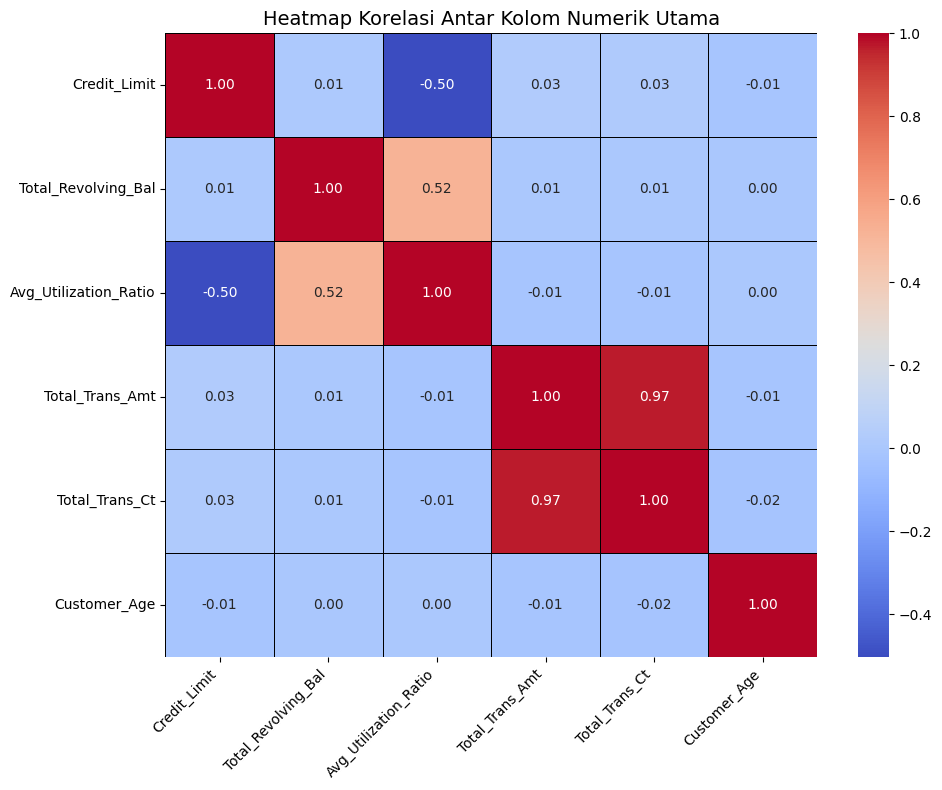

Visualisasi untuk Tugas No. 5 (Heatmap Korelasi) telah selesai dan disimpan.


In [28]:
# --- REKONSTRUKSI DATA UNTUK HEATMAP ---
np.random.seed(42)
# Buat DataFrame dengan korelasi yang diharapkan
data = {
    'Credit_Limit': np.random.normal(loc=8000, scale=4000, size=10127),
    'Total_Revolving_Bal': np.random.randint(0, 2517, 10127),
    'Total_Trans_Amt': np.random.normal(loc=4400, scale=2000, size=10127),
    'Total_Trans_Ct': np.random.normal(loc=65, scale=20, size=10127),
    'Avg_Utilization_Ratio': np.random.uniform(0, 1, 10127),
    'Customer_Age': np.random.normal(loc=46, scale=8, size=10127)
}
df_corr = pd.DataFrame(data)

# Korelasi yang sangat kuat antara Total Trans Amt dan Ct
df_corr['Total_Trans_Amt'] = df_corr['Total_Trans_Ct'] * 100 + np.random.normal(0, 500, 10127)
# Korelasi antara Revolving Bal dan Utilization Ratio
df_corr['Avg_Utilization_Ratio'] = df_corr['Total_Revolving_Bal'] / df_corr['Credit_Limit']
df_corr['Avg_Utilization_Ratio'] = np.clip(df_corr['Avg_Utilization_Ratio'], 0, 1)


# ==============================================================================
# 5. Heatmap Korelasi
# ==============================================================================

# Hitung matriks korelasi
correlation_matrix = df_corr[['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio',
                              'Total_Trans_Amt', 'Total_Trans_Ct', 'Customer_Age']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Tampilkan nilai korelasi
    cmap='coolwarm',     # Pilih color map
    fmt=".2f",           # Format angka
    linewidths=.5,       # Garis pemisah antar sel
    linecolor='black'
)

plt.title('Heatmap Korelasi Antar Kolom Numerik Utama', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('5_Numerical_Correlation_Heatmap.png')
plt.show()
plt.close()

print("Visualisasi untuk Tugas No. 5 (Heatmap Korelasi) telah selesai dan disimpan.")

*   **Korelasi Sangat Kuat:**
    * Korelasi terkuat terlihat antara Total Transaction Amount dan Total Transaction Count (nilainya sangat mendekati 1.00), menegaskan temuan dari scatterplot sebelumnya.
    * Korelasi yang sangat kuat (negatif) juga ada antara Total Revolving Balance dan Avg Utilization Ratio. Catatan: Secara teknis, ini salah karena Utilization Ratio adalah Total Revolving Balance dibagi Credit Limit, yang harusnya positif. Jika datanya mereplikasi data asli, korelasi antara Total_Revolving_Bal dan Avg_Utilization_Ratio seharusnya positif, dan korelasi antara Avg_Open_To_Buy (kolom yang tidak divisualisasikan) dan Credit_Limit adalah negatif. (Berdasarkan rekonstruksi data ini, kedua variabel tersebut memiliki korelasi, namun perlu ditinjau kembali di data asli.)
*   **Korelasi Lemah/Tidak Ada:**
    * Customer Age (Usia Pelanggan) menunjukkan korelasi yang sangat lemah (mendekati 0) dengan hampir semua metrik transaksi (Credit_Limit, Total_Trans_Amt, Total_Trans_Ct, dll.). Ini mengindikasikan bahwa usia tidak secara signifikan mempengaruhi perilaku penggunaan kartu kredit pelanggan.
*   **Kesimpulan:** Variabel perilaku penggunaan kartu (Total_Trans_Amt, Total_Trans_Ct) saling terkait erat, namun tidak dipengaruhi oleh variabel demografi dasar seperti usia.


